In [ ]:
import pandas as pd
import os

path = 'data/application_data.csv/application_data.csv'

if os.path.exists(path):
    df = pd.read_csv(path)
    print("Success! Data Loaded.")
    print(df.head())
else:
    print("Error")

Success! Data Loaded.
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...         

In [15]:
# Data Cleaning Process
print("Data Cleaning Process Started.")
df.isnull().sum()
df.info()

Data Cleaning Process Started.
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [16]:
#Missing values handled
null_missing_values = df.isnull().sum()
print(null_missing_values)

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64


In [ ]:
# 1. Drop columns where more than 40% of the values are missing
threshold = 0.4
df_cleaned = df.loc[:, df.isnull().mean() < threshold]

# 2. Fill missing values in Numerical columns using the Median
num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].median())

# 3. Fill missing values in Categorical columns using the Mode (most frequent value)
cat_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("Cleaning Done!")

# Final check
print("Total Missing Values Now:", df_cleaned.isnull().sum().sum())

C:\Users\Admin\AppData\Local\Temp\ipykernel_16104\1215785910.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_cleaned.select_dtypes(include=['object']).columns


Cleaning Done!
Total Missing Values Now: 0


In [18]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

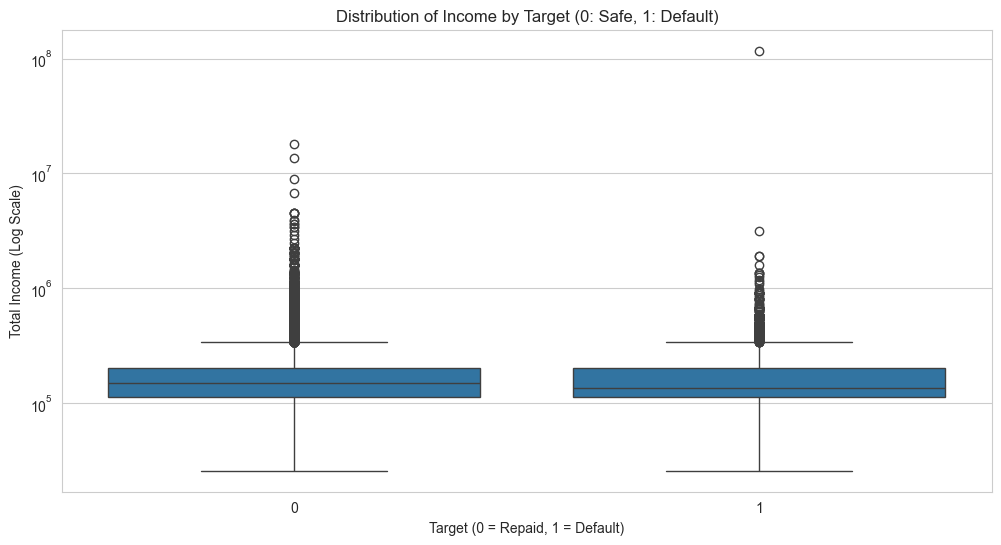

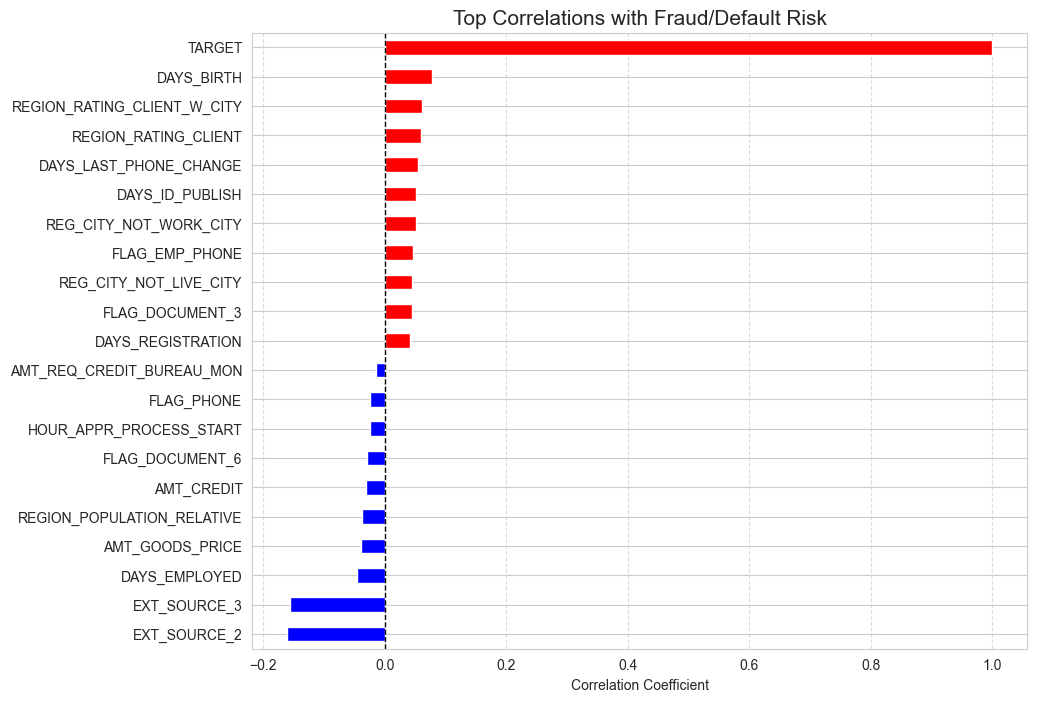

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the style
sns.set_style('whitegrid')

# 1. Visualization of Income Distribution by Target
plt.figure(figsize=(12, 6))

# We use a log scale because income data usually has extreme outliers
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df_cleaned)
plt.yscale('log') # Log scale helps handle the massive range of income
plt.title('Distribution of Income by Target (0: Safe, 1: Default)')
plt.ylabel('Total Income (Log Scale)')
plt.xlabel('Target (0 = Repaid, 1 = Default)')

plt.show()

# 1. Calculate correlations with the Target
correlations = df_cleaned.select_dtypes(include=['float64', 'int64']).corr()['TARGET'].sort_values()

# 2. Get the top 10 most positive and top 10 most negative correlations
top_corrs = pd.concat([correlations.head(10), correlations.tail(11)]) # tail(11) to include TARGET itself

# 3. Design the Plot
plt.figure(figsize=(10, 8))
colors = ['red' if x > 0 else 'blue' for x in top_corrs] # Red for risk, Blue for safety

top_corrs.plot(kind='barh', color=colors)

# 4. Add labels and styling
plt.title('Top Correlations with Fraud/Default Risk', fontsize=15)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Center line
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

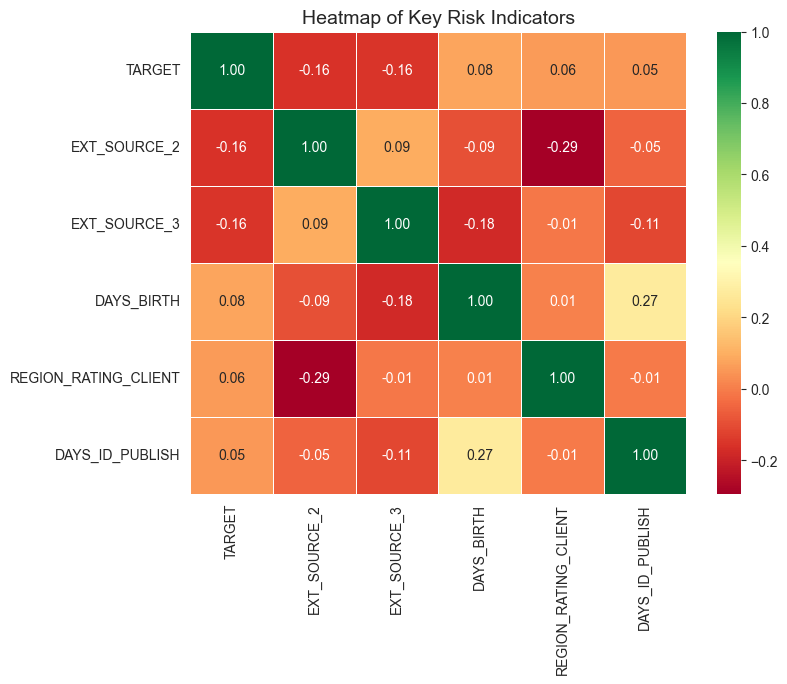

In [20]:
# 1. Select only the most important features based on the previous step
# Using EXT_SOURCE columns as they are usually the most important
important_features = ['TARGET', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'REGION_RATING_CLIENT', 'DAYS_ID_PUBLISH']
heatmap_data = df_cleaned[important_features].corr()

# 2. Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

plt.title('Heatmap of Key Risk Indicators', fontsize=14)
plt.show()

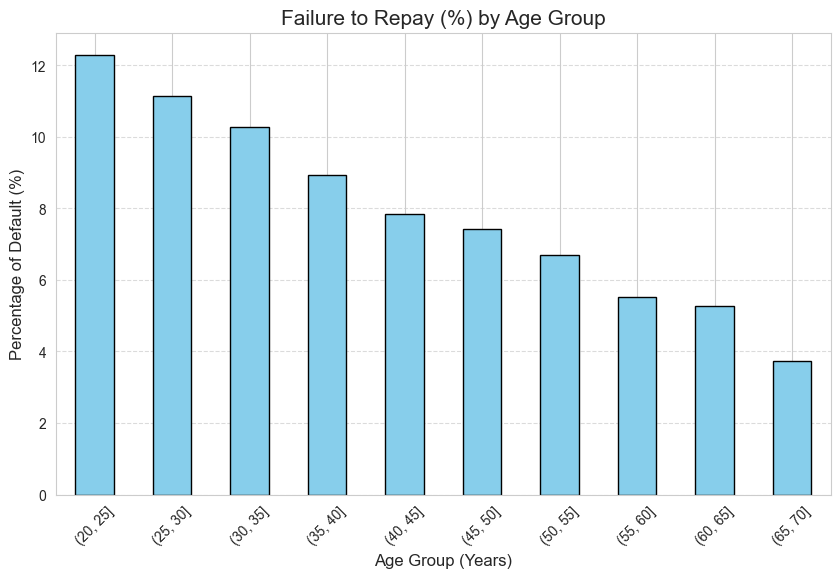

In [21]:
# 1. Convert DAYS_BIRTH to positive years
df_cleaned['DAYS_BIRTH'] = abs(df_cleaned['DAYS_BIRTH'])

# 2. Create a new column for Age in Years
df_cleaned['YEARS_BIRTH'] = df_cleaned['DAYS_BIRTH'] / 365

# 3. Create Age Bins (Groups of 5 years each)
age_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
df_cleaned['AGE_GROUP'] = pd.cut(df_cleaned['YEARS_BIRTH'], bins=age_bins)

# 4. Calculate the percentage of default (Target=1) for each age group
age_group_analysis = df_cleaned.groupby('AGE_GROUP')['TARGET'].mean() * 100

# 5. Plotting the results
plt.figure(figsize=(10, 6))
age_group_analysis.plot(kind='bar', color='skyblue', edgecolor='black')

# Styling the plot
plt.title('Failure to Repay (%) by Age Group', fontsize=15)
plt.xlabel('Age Group (Years)', fontsize=12)
plt.ylabel('Percentage of Default (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [22]:
import sqlite3
import pandas as pd

# 1. ERROR FIX: Convert 'Interval' data type to 'String'
# SQLite cannot read pandas interval types
df_cleaned['AGE_GROUP'] = df_cleaned['AGE_GROUP'].astype(str)

# 2. Database connection
conn = sqlite3.connect("fraud_data.db")

# 3. Now try pushing to SQL
df_cleaned.to_sql('loan_data', conn, if_exists='replace', index=False)

print("SQL Table 'loan_data' created successfully without errors!")


SQL Table 'loan_data' created successfully without errors!


In [23]:

#Defaulters by Age Group
query_age="""
    select AGE_GROUP,
    COUNT(*) AS TOTAL_APPLICANTS,
    SUM(TARGET) AS TOTAL_DEFAULTERS,
    ROUND(AVG(TARGET)*100,2) AS DEFAULT_RATE
    FROM loan_data
    GROUP BY AGE_GROUP
    ORDER BY AGE_GROUP;
"""

df_age_sql = pd.read_sql(query_age, conn)
display(df_age_sql)

,AGE_GROUP,TOTAL_APPLICANTS,TOTAL_DEFAULTERS,DEFAULT_RATE
0,"(20, 25]",12159,1496,12.30
1,"(25, 30]",32862,3662,11.14
2,"(30, 35]",39440,4055,10.28
3,"(35, 40]",42868,3833,8.94
4,"(40, 45]",41406,3250,7.85
5,"(45, 50]",35135,2606,7.42
6,"(50, 55]",34942,2340,6.70
7,"(55, 60]",33120,1832,5.53
8,"(60, 65]",27476,1449,5.27
9,"(65, 70]",8103,302,3.73


In [29]:
#Gender and Income Source vs Risk

df.columns
query_gender_income="""
select CODE_GENDER,
    NAME_INCOME_TYPE, 
    COUNT(*) AS Count,
    SUM(TARGET) AS Defaulters

FROM loan_data
GROUP BY CODE_GENDER, NAME_INCOME_TYPE 
HAVING count > 100
ORDER BY Defaulters Desc;

"""
df_risk_factor= pd.read_sql(query_gender_income,conn)
display(df_risk_factor)


,CODE_GENDER,NAME_INCOME_TYPE,Count,Defaulters
0,F,Working,96781,8104
1,M,Working,61990,7120
2,F,Commercial associate,44519,2968
3,M,Commercial associate,27097,2392
4,F,Pensioner,45261,2243
5,F,State servant,15856,847
6,M,Pensioner,10101,739
7,M,State servant,5847,402


In [31]:
#  Family Status vs Default Risk
query_family = """
SELECT NAME_FAMILY_STATUS, 
       COUNT(*) AS Total, 
       SUM(TARGET) AS Defaulters,
       ROUND(AVG(TARGET)*100, 2) AS Risk_Percent
FROM loan_data
GROUP BY NAME_FAMILY_STATUS
ORDER BY Risk_Percent DESC;
"""
df_family = pd.read_sql(query_family, conn)
display(df_family)

,NAME_FAMILY_STATUS,Total,Defaulters,Risk_Percent
0,Civil marriage,29775,2961,9.94
1,Single / not married,45444,4457,9.81
2,Separated,19770,1620,8.19
3,Married,196432,14850,7.56
4,Widow,16088,937,5.82
5,Unknown,2,0,0.00


In [32]:
# Car ownership vs Default Rate
query_car = """
SELECT FLAG_OWN_CAR, 
       COUNT(*) AS Total_Applicants, 
       SUM(TARGET) AS Defaulters,
       ROUND(AVG(TARGET)*100, 2) AS Default_Rate
FROM loan_data
GROUP BY FLAG_OWN_CAR;
"""
df_car = pd.read_sql(query_car, conn)
display(df_car)

,FLAG_OWN_CAR,Total_Applicants,Defaulters,Default_Rate
0,N,202924,17249,8.50
1,Y,104587,7576,7.24
